#  Image Classification — Fashion MNIST

This notebook trains a **Convolutional Neural Network (CNN)** to classify clothing items from the **Fashion MNIST** dataset using TensorFlow/Keras.

###  Dataset Info:
- **Source:** Built into `tensorflow.keras.datasets` — no manual download needed!
- **Also available at:** https://www.kaggle.com/datasets/zalando-research/fashionmnist
- **60,000** training images, **10,000** test images
- **10 classes:** T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot
- **Image size:** 28×28 grayscale

###  What we'll build:
1. Load and explore the dataset
2. Preprocess and visualize data
3. Build a CNN model
4. Train with callbacks
5. Evaluate and visualize results
6. Predict on new images


## 1.  Install & Import Libraries

In [1]:
# All libraries are pre-installed in Colab!
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(f" TensorFlow version: {tf.__version__}")
print(f" GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-06-25 12:50:01.428196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782391801.656528      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782391801.725695      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782391802.266676      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782391802.266734      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782391802.266737      58 computation_placer.cc:177] computation placer alr

 TensorFlow version: 2.19.0
 GPU available: False


2026-06-25 12:50:18.198287: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2.  Load the Fashion MNIST Dataset

The dataset is built into Keras and downloads automatically.

In [2]:
# Class labels
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(" Dataset loaded!")
print(f"   Training set:   {X_train.shape} — {len(X_train)} images")
print(f"   Test set:       {X_test.shape} — {len(X_test)} images")
print(f"   Image shape:    {X_train.shape[1:]}")
print(f"   Classes:        {len(CLASS_NAMES)}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 Dataset loaded!
   Training set:   (60000, 28, 28) — 60000 images
   Test set:       (10000, 28, 28) — 10000 images
   Image shape:    (28, 28)
   Classes:        10


## 3. Explore the Dataset

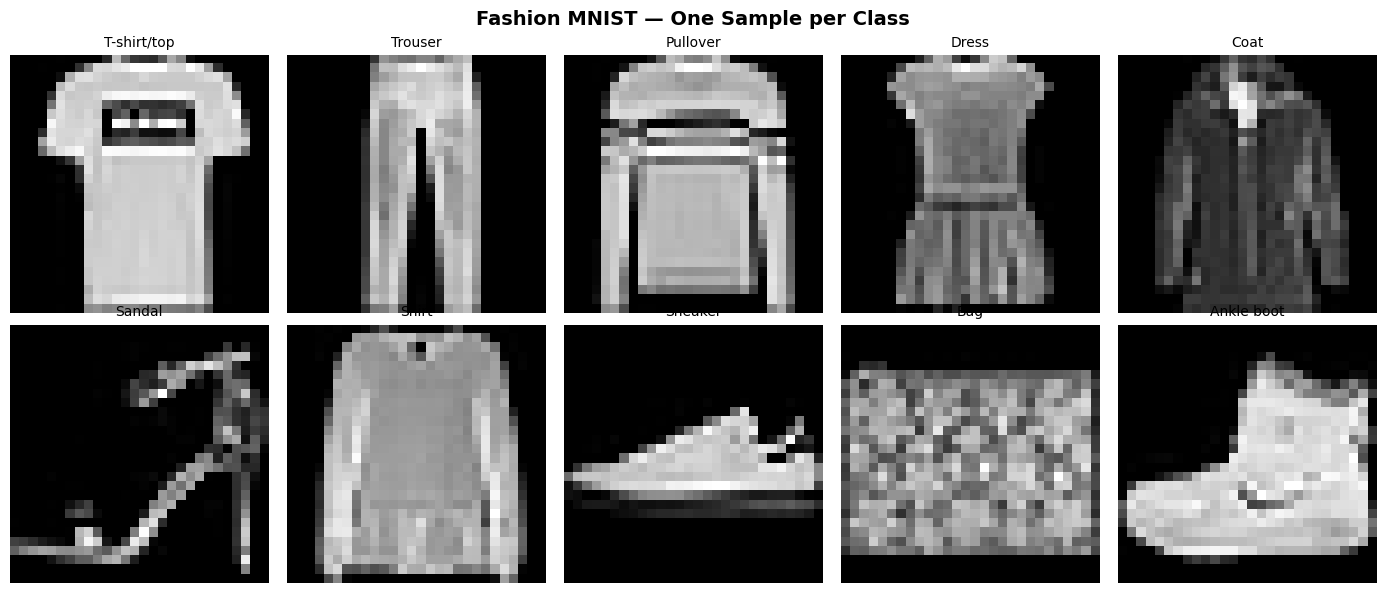

In [3]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion MNIST — One Sample per Class', fontsize=14, weight='bold')

for class_idx, ax in enumerate(axes.flat):
    # Find first image of this class
    img_idx = np.where(y_train == class_idx)[0][0]
    ax.imshow(X_train[img_idx], cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

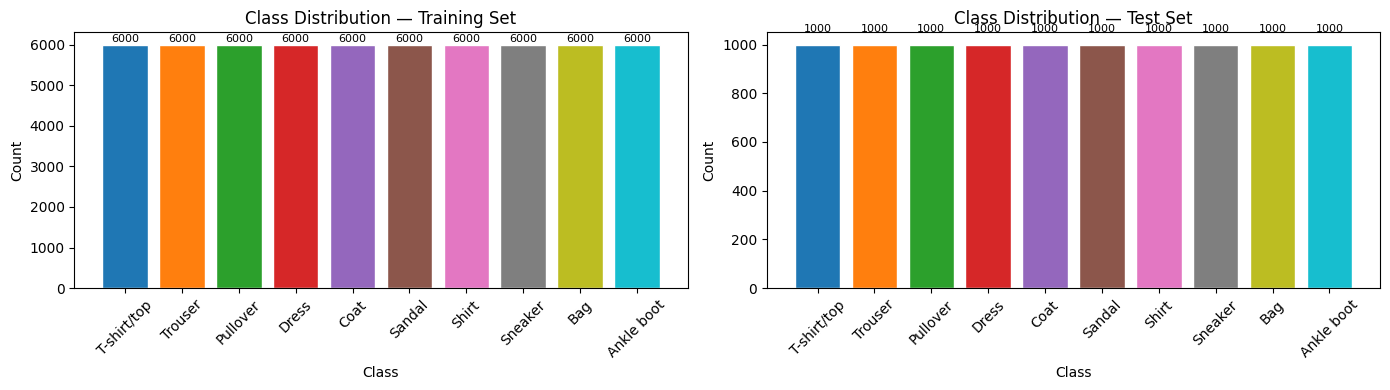

 Dataset is perfectly balanced!


In [4]:
# Check class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, labels, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    unique, counts = np.unique(labels, return_counts=True)
    bars = ax.bar([CLASS_NAMES[i] for i in unique], counts,
                  color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='white')
    ax.set_title(f'Class Distribution — {title}', fontsize=12)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(count), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print(" Dataset is perfectly balanced!")

## 4. Preprocess the Data

In [5]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Reshape for CNN: add channel dimension (28, 28) → (28, 28, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# Create validation split from training data
VAL_SIZE = 10000
X_val, y_val = X_train[:VAL_SIZE], y_train[:VAL_SIZE]
X_train, y_train = X_train[VAL_SIZE:], y_train[VAL_SIZE:]

print(" Data preprocessed and split:")
print(f"   Train:      {X_train.shape}")
print(f"   Validation: {X_val.shape}")
print(f"   Test:       {X_test.shape}")
print(f"   Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

 Data preprocessed and split:
   Train:      (50000, 28, 28, 1)
   Validation: (10000, 28, 28, 1)
   Test:       (10000, 28, 28, 1)
   Pixel range: [0.0, 1.0]


## 5.  Build the CNN Model

In [6]:
def build_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    """Build a CNN for Fashion MNIST classification."""
    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Dense head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='FashionMNIST_CNN')
    
    return model

model = build_cnn_model()
model.summary()

Model: "FashionMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,506 (1.67 MB)

 Trainable params: 437,546 (1.67 MB)

 Non-trainable params: 960 (3.75 KB)

## 6.  Compile the Model

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
cb_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_fashion_model.keras', save_best_only=True,
                              monitor='val_accuracy', verbose=1)
]

print(" Model compiled!")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Loss:      Sparse Categorical Crossentropy")
print(f"   Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")

 Model compiled!
   Optimizer: Adam (lr=0.001)
   Loss:      Sparse Categorical Crossentropy
   Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


## 7.  Train the Model

In [8]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

print(f"\n Training complete! Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/10
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7217 - loss: 0.8032
Epoch 1: val_accuracy improved from None to 0.83070, saving model to best_fashion_model.keras

Epoch 1: finished saving model to best_fashion_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 137ms/step - accuracy: 0.7880 - loss: 0.5853 - val_accuracy: 0.8307 - val_loss: 0.9257 - learning_rate: 0.0100
Epoch 2/10
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8524 - loss: 0.4088
Epoch 2: val_accuracy improved from 0.83070 to 0.89140, saving model to best_fashion_model.keras

Epoch 2: finished saving model to best_fashion_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.8607 - loss: 0.3835 - val_accuracy: 0.8914 - val_loss: 0.3037 - learning_rate: 0.0100
Epoch 3/10
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8697 - loss: 0.3587
Epoch 3: val_accuracy did not improve from 0.89140
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.8714 - loss: 0.3527 - val

## 8.  Training History

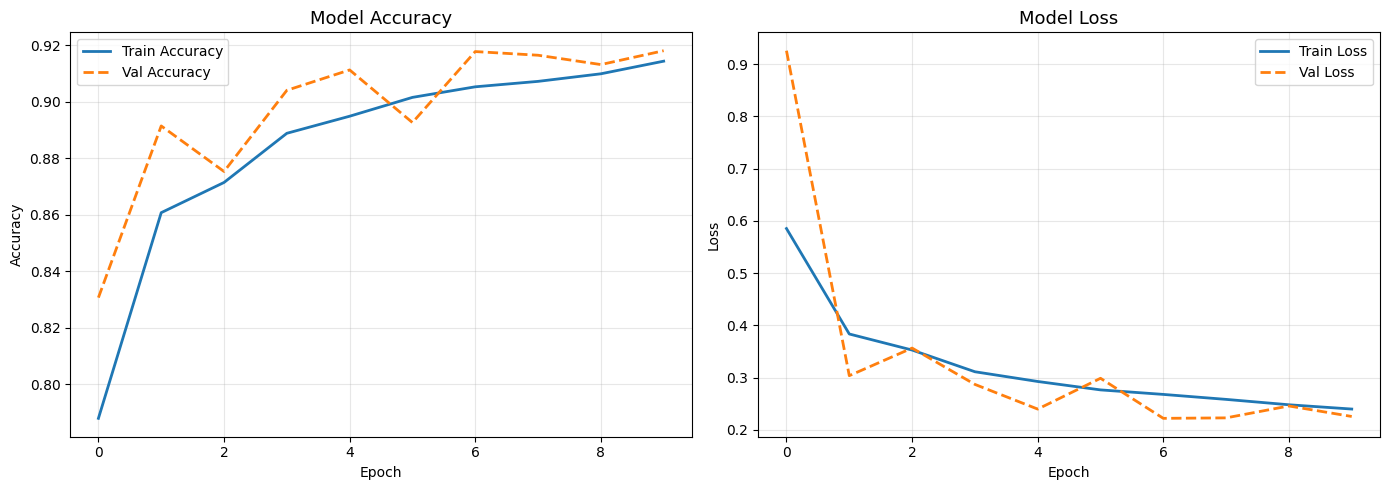

In [9]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
    axes[0].set_title('Model Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
    axes[1].set_title('Model Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(history)

## 9.  Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Accuracy: {test_acc*100:.2f}%")
print(f" Test Loss:     {test_loss:.4f}")

 Test Accuracy: 91.18%
 Test Loss:     0.2513


## 10.  Confusion Matrix

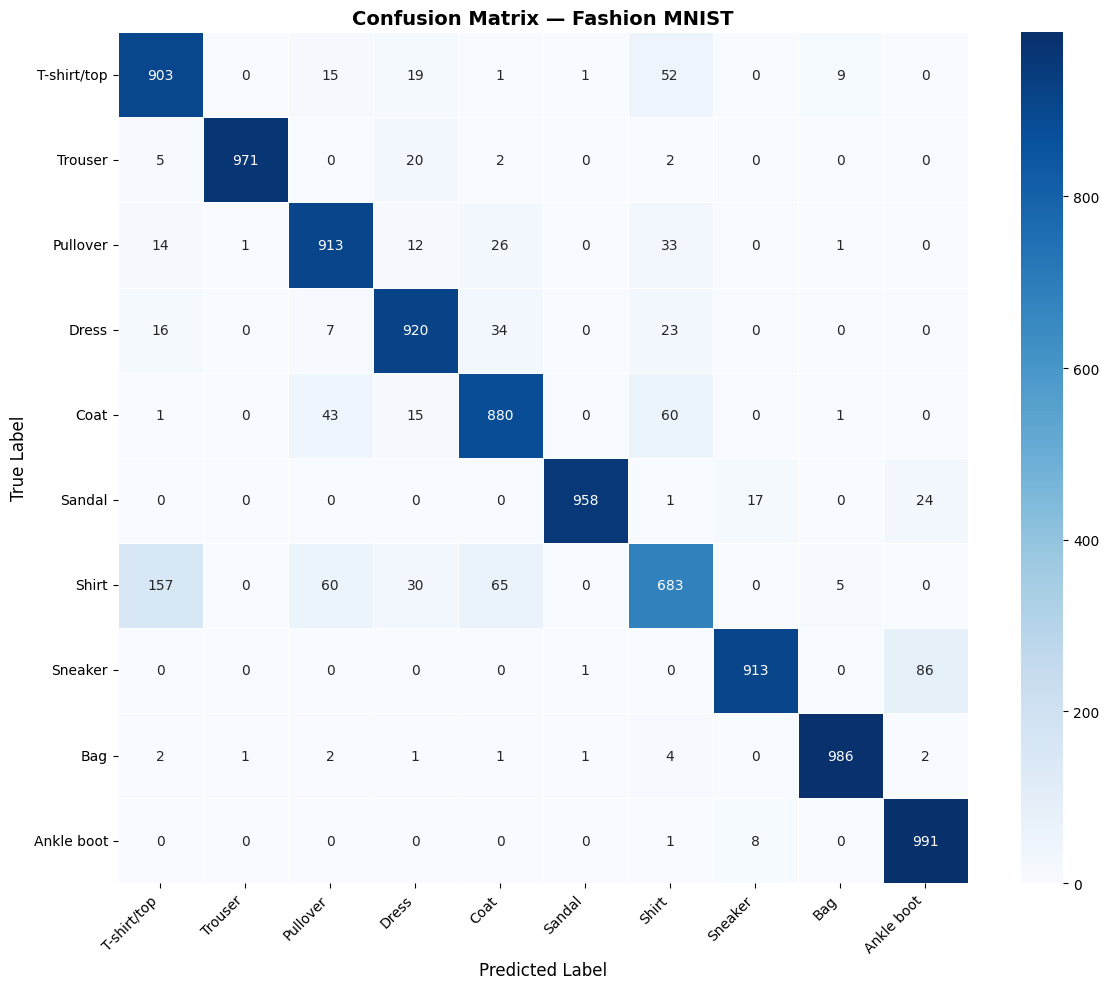


 Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.90      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.88      0.91      0.90      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.87      0.88      0.88      1000
      Sandal       1.00      0.96      0.98      1000
       Shirt       0.80      0.68      0.73      1000
     Sneaker       0.97      0.91      0.94      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.90      0.99      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [11]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Fashion MNIST', fontsize=14, weight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## 11.  Predict on Sample Images

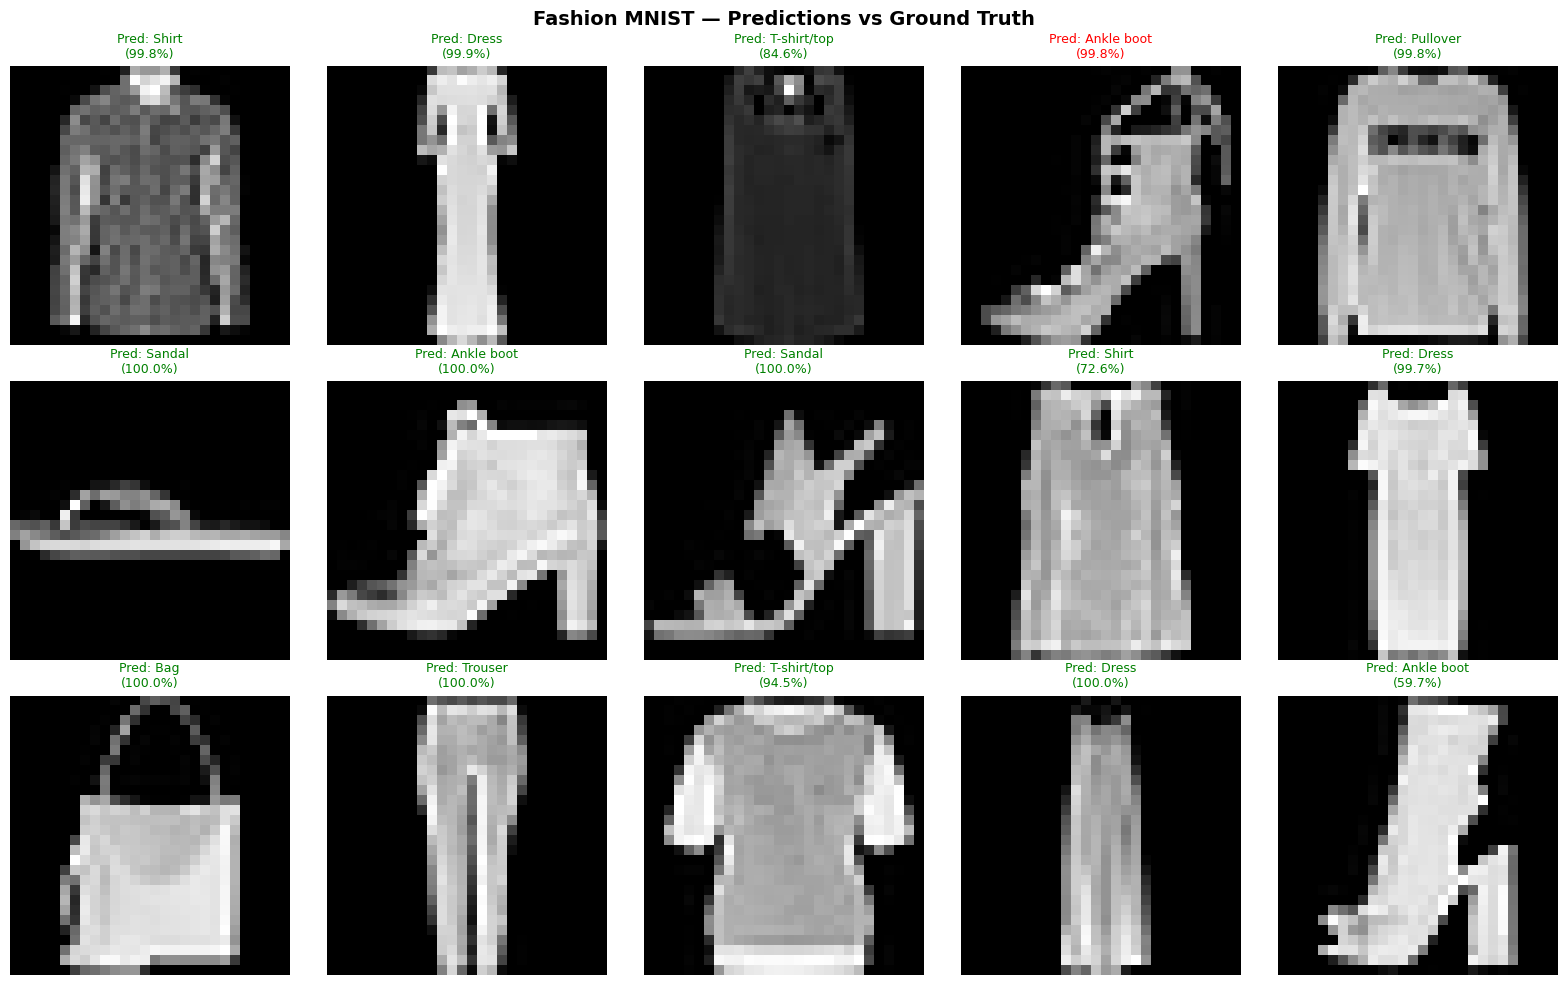

 Green = Correct |  Red = Wrong


In [12]:
# Show 15 random predictions from the test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Fashion MNIST — Predictions vs Ground Truth', fontsize=14, weight='bold')

for ax, idx in zip(axes.flat, sample_indices):
    img = X_test[idx]
    pred_probs = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred_class = np.argmax(pred_probs)
    true_class = y_test[idx]
    confidence = pred_probs[pred_class] * 100
    
    ax.imshow(img.squeeze(), cmap='gray')
    
    is_correct = pred_class == true_class
    color = 'green' if is_correct else 'red'
    label = f"Pred: {CLASS_NAMES[pred_class]}\n({confidence:.1f}%)"
    ax.set_title(label, color=color, fontsize=9)
    ax.set_xlabel(f"True: {CLASS_NAMES[true_class]}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(" Green = Correct |  Red = Wrong")

## 12.  Misclassified Examples

Total misclassified: 882 / 10000 (8.8%)


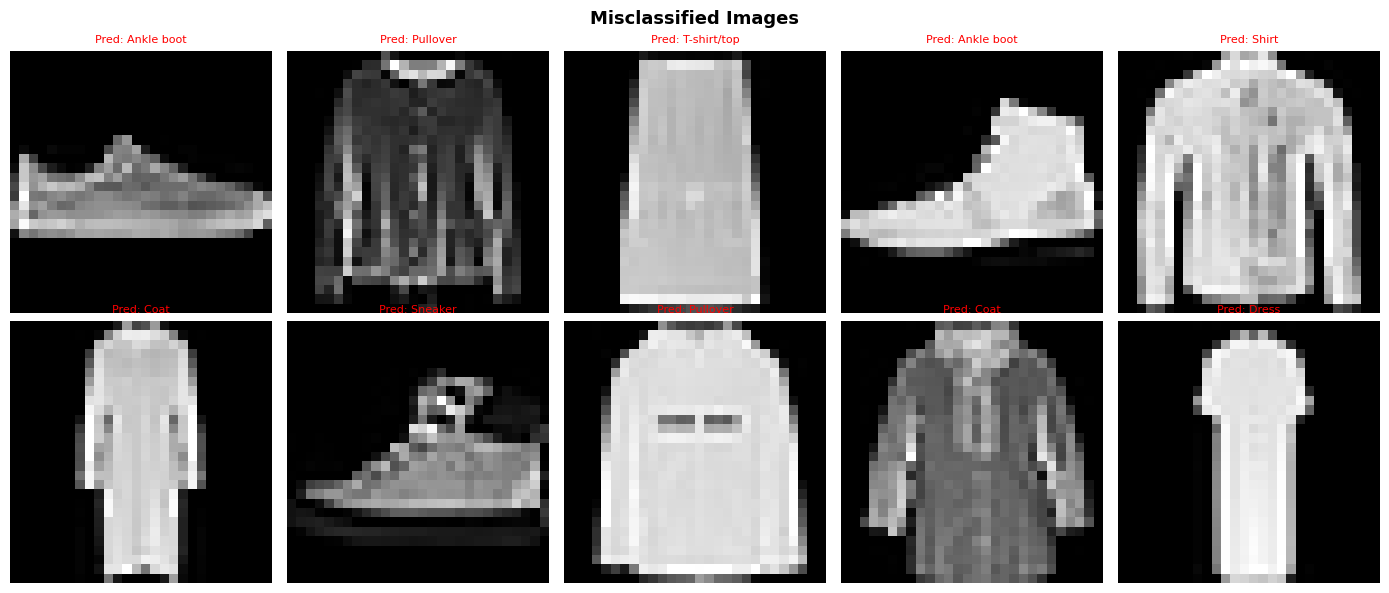

In [13]:
# Show a few wrong predictions
wrong_indices = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_indices)} / {len(y_test)} ({len(wrong_indices)/len(y_test)*100:.1f}%)")

show_count = min(10, len(wrong_indices))
sample_wrong = wrong_indices[:show_count]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Misclassified Images', fontsize=13, weight='bold')

for ax, idx in zip(axes.flat, sample_wrong):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'Pred: {CLASS_NAMES[y_pred[idx]]}', color='red', fontsize=8)
    ax.set_xlabel(f'True: {CLASS_NAMES[y_test[idx]]}', color='green', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()